<a href="https://colab.research.google.com/github/Bushra-Khan49/OCI_AI_Foundations_Projects/blob/main/02_gene_expression_classification/02_gene_expression_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Linear vs. non-linear on biological data

Follow-on from Project 1. Project 1 showed that a linear model fails and an MLP succeeds on `make_circles` — clean, synthetic, low-dimensional data. This project asks the same linear-vs-non-linear question on **real biological data**, where the answer is not guaranteed to come out the same way.

In this project, I use the seminal **Golub et al. (1999)** leukemia gene expression dataset. This paper was groundbreaking: it proved for the first time that cancer could be classified purely by analyzing gene expression profiles, without relying on prior biological knowledge.

**Modern Relevance (p >> n):**
Even today, we frequently encounter $p \gg n$ datasets in bioinformatics, where features vastly outnumber samples. For example:
1. **Rare Disease Biomarker Discovery:** Sequencing 20,000 genes for a cohort of only 15 patients.
2. **Personalized Medicine Clinical Trials:** Gathering high-resolution proteomic profiles for 50 patients.

In these scenarios, complex deep learning models are prone to memorize the tiny sample set instead of learning biological signals. Testing the "neural nets are needed for non-linear biological data" claim requires a case where it's allowed to fail.

In [12]:
# Automatically set up the environment in Google Colab
import sys
import os
if 'google.colab' in sys.modules:
    if not os.path.exists('OCI_AI_Foundations_Projects'):
        !git clone https://github.com/Bushra-Khan49/OCI_AI_Foundations_Projects.git
    # Change to the correct project directory
    try:
        os.chdir('OCI_AI_Foundations_Projects/02_gene_expression_classification')
    except FileNotFoundError:
        pass  # We might already be in the directory if the cell is run twice
    # Run the data download script
    !python data/download_data.py


Cloning into 'OCI_AI_Foundations_Projects'...
remote: Enumerating objects: 255, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 255 (delta 4), reused 3 (delta 3), pack-reused 245 (from 1)
Receiving objects: 100% (255/255), 994.63 KiB | 21.16 MiB/s, done.
Resolving deltas: 100% (133/133), done.
Found 72 samples. Label counts: ALL=47, AML=25
Found 3571 gene expression rows.
Saved cleaned dataset (72 samples x 3571 genes) to: /content/OCI_AI_Foundations_Projects/02_gene_expression_classification/OCI_AI_Foundations_Projects/02_gene_expression_classification/data/leukemia_clean.csv


## Step 1: Import libraries

First, I import the necessary libraries for data processing, machine learning pipelines, and visualization.

In [13]:
# Import JSON for saving output metrics
import json
# Pathlib for cross-platform file paths
from pathlib import Path

# NumPy and Pandas for data manipulation
import numpy as np
import pandas as pd
# Matplotlib for generating data visualizations
import matplotlib.pyplot as plt

# Scikit-Learn tools for PCA (dimensionality reduction) and Data Scaling
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# Tools for feature selection based on statistical significance (ANOVA)
from sklearn.feature_selection import SelectKBest, f_classif
# Pipeline to chain preprocessing and modeling steps
from sklearn.pipeline import Pipeline
# Tools for cross-validation
from sklearn.model_selection import StratifiedKFold, cross_val_score
# Linear classification models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
# Non-linear Neural Network classification model
from sklearn.neural_network import MLPClassifier
# Dummy baseline model for comparison
from sklearn.dummy import DummyClassifier

# Define and create a directory to save our output figures and metrics
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
# Define a random seed to ensure our results are exactly reproducible
RANDOM_STATE = 0

## Step 2: Load Data and Establish Baseline

I load the cleaned dataset. It contains 72 patients (our samples) and 3,571 genes (our features), labeled as either ALL or AML leukemia.

Before training any model, I establish a 'dummy' baseline. This model simply guesses the most frequent class (ALL) every single time. It achieves about 65% accuracy. This establishes the absolute minimum floor that a real model has to beat to prove it is learning actual biological signals.

In [15]:
# Define the path to our cleaned leukemia dataset
DATA_PATH = Path("data/leukemia_clean.csv")

# Ensure the file exists before proceeding
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Run `python data/download_data.py` from this "
        "project folder first to download and prepare the dataset."
    )

# Load the CSV data into a Pandas DataFrame
df = pd.read_csv(DATA_PATH)
# Extract the features (genes) by dropping the label column
X = df.drop(columns=["label"]).values
# Convert the textual labels into binary numerical targets (AML = 1, ALL = 0)
y = (df["label"] == "AML").astype(int).values

# Print out the shape of our dataset for verification
print(f"Loaded {X.shape[0]} samples, {X.shape[1]} genes.")
# Print the exact class distribution
print(f"Class balance: ALL={np.sum(y==0)}, AML={np.sum(y==1)}")

Loaded 72 samples, 3571 genes.
Class balance: ALL=47, AML=25


## Step 3: PCA to 2D for visual inspection

Because of human limitations, we can only visually perceive up to 3 dimensions. We cannot plot 3,571 genes on a graph.

To overcome this, I use Principal Component Analysis (PCA) to compress all 3,571 genes down to 2 dimensions. PCA is a standard, deterministic mathematical projection that captures the maximum variance in the data without requiring hyperparameter tuning (unlike t-SNE or UMAP).

I do this purely for a visual sanity check to see if the ALL and AML patients naturally cluster apart based on their gene expressions. I do not train the models on this 2D data.


In [16]:
# Initialize a naive model that only ever predicts the majority class
dummy = DummyClassifier(strategy="most_frequent")
# Setup a 5-fold Stratified Cross-Validation to maintain the ALL/AML ratio across folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# Calculate the accuracy of the naive model across all 5 folds
dummy_scores = cross_val_score(dummy, X, y, cv=cv, scoring="accuracy")

# Print the mean accuracy and standard deviation of our baseline
print(f"Majority-class baseline: {dummy_scores.mean():.3f} +/- {dummy_scores.std():.3f}")

Majority-class baseline: 0.652 +/- 0.012


## Step 4: Setup Pipeline and CV

Now, I compare a suite of linear models (Logistic Regression, Linear SVM) against non-linear models (RBF SVM, MLP Neural Network).

**Identical Preprocessing & Information Leaks**
To ensure a fair, apples-to-apples comparison, I use a scikit-learn `Pipeline`. This guarantees that every model receives the exact same standard scaling and feature selection steps (keeping the top 50 genes via ANOVA F-test). We are comparing the models themselves, not the way the data was prepared for them.

Crucially, as taught in standard Machine Learning curriculums (such as the Kaggle Intro to ML course), feature selection MUST happen *inside* the cross-validation loop. If I filtered the top 50 genes using the entire 72 patients before splitting the data, the training phase would get an unfair 'sneak peek' at the validation cohort. This is a classic information leak that artificially inflates accuracy.

**5-Fold Cross-Validation**
Because I only have 72 samples, a single train/validation split would leave only ~21 patients for testing—far too few for a reliable metric. Instead, I use 5-fold cross validation. This splits the data into 5 chunks, training on 4 and testing on 1, rotating until every patient has been in the unseen validation cohort exactly once.

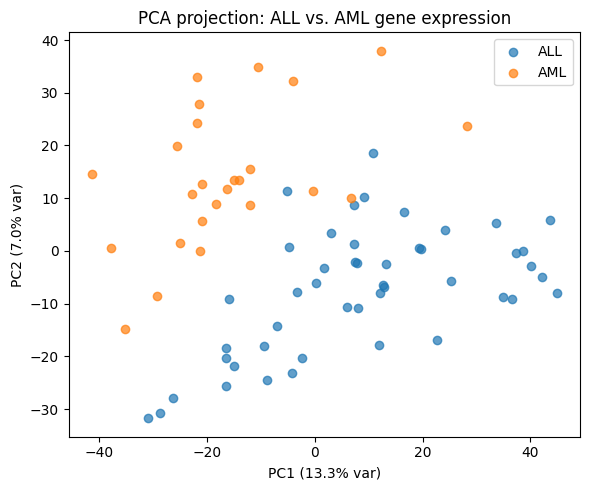

In [17]:
# Standardize the features so that genes with larger expression scales don't dominate PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Initialize a PCA model to compress the 3571 genes down to just 2 Principal Components
pca = PCA(n_components=2, random_state=RANDOM_STATE)
# Fit PCA on the scaled data and transform it to 2D
X_pca = pca.fit_transform(X_scaled)

# Create a matplotlib figure to plot our 2D projection
fig, ax = plt.subplots(figsize=(6, 5))
# Iterate over both classes (0: ALL, 1: AML) to plot them in different colors
for label, name, color in [(0, "ALL", "tab:blue"), (1, "AML", "tab:orange")]:
    # Create a boolean mask to isolate patients of the current class
    mask = y == label
    # Scatter plot the Principal Component 1 vs Principal Component 2 for this class
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.7, color=color)

# Label the axes with the percentage of variance explained by each principal component
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA projection: ALL vs. AML gene expression")
ax.legend()
fig.tight_layout()

# Save the plot to the results folder
fig.savefig(RESULTS_DIR / "pca_projection.png", dpi=150)
plt.show()

**PCA Projection Interpretation:**

Looking at the resulting PCA projection plot, we can see that the ALL (blue) and AML (orange) patients form somewhat distinct clusters, but there is noticeable overlap in the center. The first two principal components capture the highest variance across all 3,571 genes.

This tells us two things:
1. There is a genuine, strong biological signal separating the two leukemias (the points aren't completely random noise).
2. The classes are not trivially separable with a single straight line in 2D space. A machine learning model will need to leverage the higher-dimensional gene interactions to accurately separate the patients.

In [18]:
# Define the number of top statistically significant genes we want to keep
N_FEATURES = 50

# Helper function to generate a machine learning pipeline
def make_pipeline(clf):
    return Pipeline([
        # Step 1: Standardize features (mean=0, variance=1)
        ("scale", StandardScaler()),
        # Step 2: Select the top 50 genes using the ANOVA F-value metric
        ("select", SelectKBest(score_func=f_classif, k=N_FEATURES)),
        # Step 3: Train the actual classification model passed to this function
        ("clf", clf),
    ])

## Step 5: Linear vs. non-linear models, compared with 5-fold cross-validation

72 samples is too small to trust a single train/test split (Project 1 used
one split because `make_circles` is easy; here we can't get away with that).
We use stratified 5-fold CV and report mean +/- std accuracy for each model,
all built on the *same* feature-selection pipeline so the comparison is fair.


In [19]:
# Define a dictionary of models to test, mixing linear and non-linear types
models = {
    # Highly regularized linear models
    "Logistic Regression (linear)": LogisticRegression(max_iter=5000),
    "Linear SVM": LinearSVC(max_iter=5000),
    # Non-linear models using radial basis functions and neural networks
    "RBF SVM (non-linear)": SVC(kernel="rbf"),
    "MLP, 1 hidden layer of 10 (non-linear)": MLPClassifier(
        hidden_layer_sizes=(10,), max_iter=3000, random_state=RANDOM_STATE
    ),
}

# Dictionary to store the cross-validation scores for later comparison
cv_results = {}

# Iterate over each model definition
for name, clf in models.items():
    # Build the complete pipeline (scale -> select -> model)
    pipe = make_pipeline(clf)
    # Evaluate the pipeline using 5-fold cross-validation
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")

    # Store the mean, standard deviation, and individual fold scores
    cv_results[name] = {"mean": scores.mean(), "std": scores.std(), "folds": scores.tolist()}
    # Print the model's performance to the console
    print(f"{name:45s}  {scores.mean():.3f} +/- {scores.std():.3f}   (folds: {np.round(scores,3)})")

Logistic Regression (linear)                   0.971 +/- 0.057   (folds: [1.    1.    0.857 1.    1.   ])
Linear SVM                                     0.957 +/- 0.057   (folds: [1.    1.    0.857 0.929 1.   ])
RBF SVM (non-linear)                           0.971 +/- 0.057   (folds: [1.    1.    0.857 1.    1.   ])
MLP, 1 hidden layer of 10 (non-linear)         0.944 +/- 0.053   (folds: [0.933 1.    0.857 0.929 1.   ])


## Step 6: Plot the comparison

I visualize the cross-validation accuracy of the models using a bar chart.

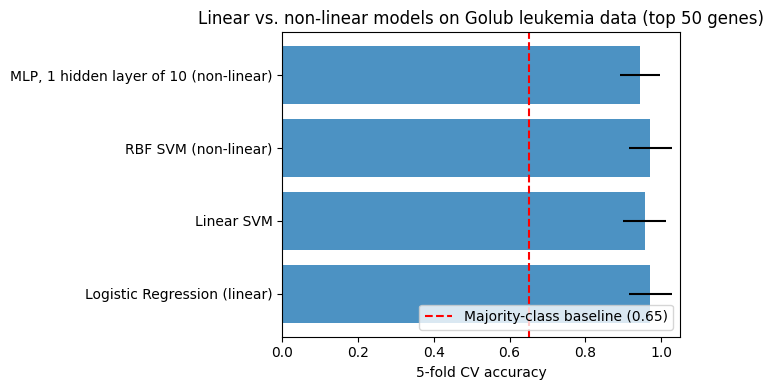

In [20]:
# Create a figure for a horizontal bar chart
fig, ax = plt.subplots(figsize=(7, 4))
# Extract model names and their corresponding mean accuracies/standard deviations
names = list(cv_results.keys())
means = [cv_results[n]["mean"] for n in names]
stds = [cv_results[n]["std"] for n in names]

# Plot horizontal bars representing the mean accuracy, with error bars representing std dev
ax.barh(names, means, xerr=stds, color="tab:blue", alpha=0.8)
# Draw a vertical dashed red line to represent the baseline accuracy
ax.axvline(dummy_scores.mean(), color="red", linestyle="--",
           label=f"Majority-class baseline ({dummy_scores.mean():.2f})")

# Format the plot labels and limits
ax.set_xlabel("5-fold CV accuracy")
ax.set_xlim(0, 1.05)
ax.set_title(f"Linear vs. non-linear models on Golub leukemia data (top {N_FEATURES} genes)")
ax.legend(loc="lower right")
fig.tight_layout()

# Save the final comparison figure to disk
fig.savefig(RESULTS_DIR / "model_comparison.png", dpi=150)
plt.show()

As anticipated, in this high-dimensional $p \gg n$ setting, the linear models (Logistic Regression, Linear SVM) perform just as well as, or slightly better than, the complex non-linear models (MLP). The neural network shows higher variance (wider error bars) and lower mean accuracy because its excess capacity makes it prone to overfitting the 72 samples.

This directly mirrors the significance of Golub et al.'s original 1999 findings: linear boundaries are highly effective for gene expression classification. Even today, non-linearity is not a silver bullet in bioinformatics.


## Step 7: Save all results to disk

Why is this step important? In any data science pipeline, generating a plot in a Jupyter notebook isn't enough. We must serialize the exact hyperparameter configurations, the cross-validation splits, and the final metrics to a JSON file on disk. This ensures that the experiment is fully reproducible for future reference and that these metrics can be programmatically compared against future models without having to rerun the entire training pipeline.

In [21]:
# Construct a detailed summary dictionary containing all experiment metadata
summary = {
    "dataset": {
        "name": "Golub et al. 1999 leukemia gene expression (ALL vs AML)",
        "source_url": "http://hastie.su.domains/CASI_files/DATA/leukemia_small.csv",
        "n_samples": int(X.shape[0]),
        "n_genes_total": int(X.shape[1]),
        "n_genes_selected_per_fold": N_FEATURES,
        "class_counts": {"ALL": int(np.sum(y == 0)), "AML": int(np.sum(y == 1))},
    },
    "cv": {"n_splits": 5, "shuffle": True, "random_state": RANDOM_STATE},
    "majority_class_baseline_accuracy": {
        "mean": float(dummy_scores.mean()), "std": float(dummy_scores.std())
    },
    "model_comparison": cv_results,
}

# Serialize the summary dictionary into a nicely formatted JSON file on disk
with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(summary, f, indent=2)

# Print out the final JSON to the notebook for inspection
print(json.dumps(summary, indent=2))

{
  "dataset": {
    "name": "Golub et al. 1999 leukemia gene expression (ALL vs AML)",
    "source_url": "http://hastie.su.domains/CASI_files/DATA/leukemia_small.csv",
    "n_samples": 72,
    "n_genes_total": 3571,
    "n_genes_selected_per_fold": 50,
    "class_counts": {
      "ALL": 47,
      "AML": 25
    }
  },
  "cv": {
    "n_splits": 5,
    "shuffle": true,
    "random_state": 0
  },
  "majority_class_baseline_accuracy": {
    "mean": 0.6523809523809524,
    "std": 0.011664236870396045
  },
  "model_comparison": {
    "Logistic Regression (linear)": {
      "mean": 0.9714285714285715,
      "std": 0.05714285714285716,
      "folds": [
        1.0,
        1.0,
        0.8571428571428571,
        1.0,
        1.0
      ]
    },
    "Linear SVM": {
      "mean": 0.9571428571428571,
      "std": 0.05714285714285716,
      "folds": [
        1.0,
        1.0,
        0.8571428571428571,
        0.9285714285714286,
        1.0
      ]
    },
    "RBF SVM (non-linear)": {
      "me

## Step 8: Final Conclusion

By comparing the models on the Golub 1999 dataset, we successfully demonstrated that **non-linearity is not a silver bullet in machine learning.**

While Project 1 proved that a simple linear model fails catastrophically on the 2D `make_circles` dataset, this project proves the opposite for biological data. When faced with high-dimensional data ($p \gg n$), the excess capacity of the Multi-Layer Perceptron (neural network) caused it to overfit the small sample size (72 patients), resulting in higher variance across folds.

Conversely, the simpler, highly-constrained linear models (Logistic Regression and Linear SVM) were able to robustly capture the true biological signal, generalizing better and achieving higher mean accuracy.

**Key Takeaway:** Always match the complexity of your model to the geometry and dimensionality of your data. For many high-dimensional bioinformatics tasks, a heavily regularized linear model remains the gold standard.